In [1]:
import tensorflow as tf
import random
import numpy as np
import matplotlib.pyplot as plt

División de los datos

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Acá el shape inicial es (60000, 28, 28) que representa 60000 imágenes de 28x28 pixels cada una
# Cada pixel tiene un valor entre 0 y 255 que representa la intensidad de la luz
# 0 es el color negro y 255 es el color blanco

# Realmente debería de ser (60000,28,28,1) donde:
# 60000 es el número de imágenes
# 28 es el ancho de la imagen
# 28 es el alto de la imagen
# 1 es el canal de la imagen (grayscale)

# Todo es distinto a un valor RGB, donde si se tiene un valor de 0, 0, 0, se tiene el color negro
# Si se tiene un valor de 255, 255, 255, se tiene el color blanco
# Si se tiene un valor de 128, 128, 128, se tiene el color gris
# Si se tiene un valor de 255, 0, 0, se tiene el color rojo
# Si se tiene un valor de 0, 255, 0, se tiene el color verde
# Si se tiene un valor de 0, 0, 255, se tiene el color azul


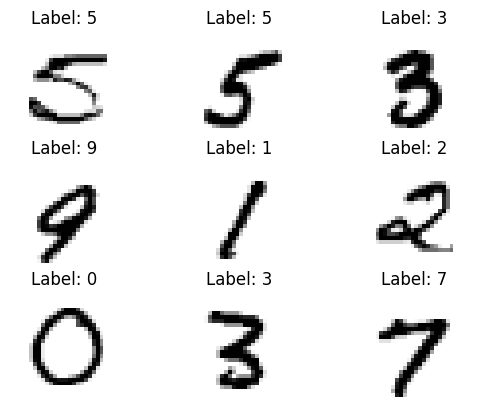

In [3]:
plt.figure()
for i in range(9):
    index = random.randint(0, len(x_train))
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[index], cmap=plt.cm.binary)
    plt.title(f"Label: {y_train[index]}")
    plt.axis('off')
plt.show()


- Vamos a ver tecnicas de data augmentation-
- Generar data sintetica
- Estas pqueñas diferencias entre clases la red tiene que aprender a reconocerlas


Normalización de los datos

In [4]:
# Normalización de datos, llevan los datos a un rango de 0 a 1
# (0-255) -> (0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_train.shape[0]

60000

Flatten o aplanar los datos

In [7]:
# Ahora debemos aplanar los datos para que sean un vector de 784 elementos
# 60000,28,28 -> 60000,784
# 60000 imágenes de 28x28 pixels
# 60000 x 28 x 28 = 47040000 elementos

x_train = x_train.reshape(x_train.shape[0], 28*28)
x_test = x_test.reshape(x_test.shape[0], 28*28)

# x_train=x_train.reshape(-1,28*28)
# x_test=x_test.reshape(-1,28*28)


In [8]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


¿? Se necesita revisar al momento de aplanar como se visualiza la información

Aplicar one-hot encoding sobre el target

In [9]:
# Aplicando one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(y_train.shape)
print(y_test.shape)

print(x_train.shape)
print(x_test.shape)

(60000, 10)
(10000, 10)
(60000, 784)
(10000, 784)


¿? Buscar información de porque se aplana y como se representa

Definir el modelo

In [10]:
# Definir el modelo
modelo=tf.keras.Sequential([ 
    tf.keras.layers.Dense(256, activation='relu',kernel_initializer=tf.keras.initializers.Zeros()),
    tf.keras.layers.Dense(128, activation='relu',kernel_initializer=tf.keras.initializers.Zeros()),
    tf.keras.layers.Dense(128, activation='relu',kernel_initializer=tf.keras.initializers.Zeros()),
    tf.keras.layers.Dense(10, activation='softmax',kernel_initializer=tf.keras.initializers.Zeros())
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

¿? Buscar información de Adam.

Entrenar el modelo

In [11]:
historia1=modelo.fit(
    x_train,
    y_train, 
    epochs=30, 
    batch_size=128, 
    validation_split=0.2,
    verbose=1
    )

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1129 - loss: 2.3016 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3022
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3022
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.

Evaluar el modelo

In [12]:
modelo.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - accuracy: 0.1135 - loss: 2.3010


[2.301028251647949, 0.11349999904632568]

Graficar la función pérdida

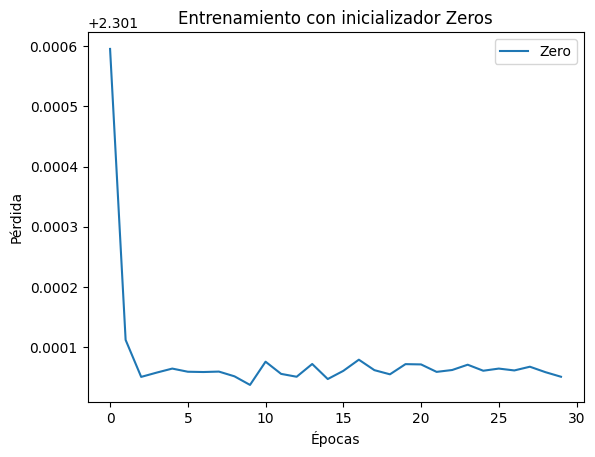

In [13]:
plt.figure()
plt.plot(historia1.history['loss'], label='Zero')
plt.title("Entrenamiento con inicializador Zeros")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

Se creará una función para comparar los inicializadores

In [14]:
def crearModelo(inicializador):
    modelo=tf.keras.Sequential([ 
        tf.keras.layers.Dense(256, activation='relu',kernel_initializer=inicializador),
        tf.keras.layers.Dense(128, activation='relu',kernel_initializer=inicializador),
        tf.keras.layers.Dense(128, activation='relu',kernel_initializer=inicializador),
        tf.keras.layers.Dense(10, activation='softmax',kernel_initializer=inicializador)
    ])
    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy', metrics=['accuracy'])
    return modelo

In [15]:
inicializadores = {
    "Zeros": tf.keras.initializers.Zeros(),
    "RandomNormal": tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.1),
    "HeNormal": tf.keras.initializers.HeNormal(),
}

historias = {}

for name, inicializador in inicializadores.items():
    print(f"Entrenando con inicializador {name}")
    tf.keras.backend.clear_session()
    modelo = crearModelo(inicializador)

    modelo.build((None, 784))
    ejemploPesos = modelo.layers[1].get_weights()[0].flatten()[:10]
    print(f"Primeros 10 pesos: {ejemploPesos}")

    historia = modelo.fit(
        x_train, y_train,
        epochs=30,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    historias[name] = historia

Entrenando con inicializador Zeros
Primeros 10 pesos: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1135 - loss: 2.3017 - val_accuracy: 0.1060 - val_loss: 2.3019
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 8/30
375/375

Plotear los resultados

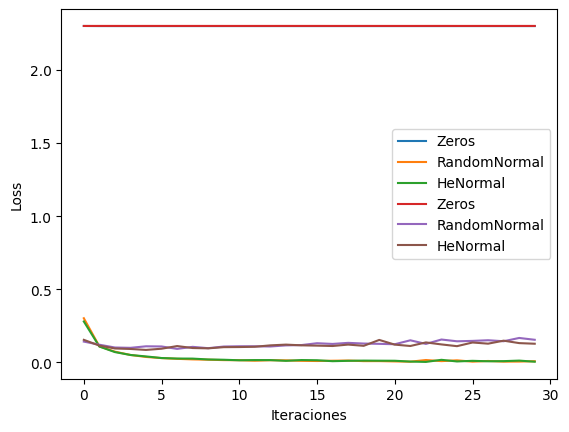

In [23]:
plt.figure()

# for nombre, historia in historias.items():
    # plt.plot(historias.history['loss'], label=nombre) 
plt.plot(historias['Zeros'].history['loss'], label='Zeros')
plt.plot(historias['RandomNormal'].history['loss'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['loss'], label='HeNormal')
plt.plot(historias['Zeros'].history['val_loss'], label='Zeros')
plt.plot(historias['RandomNormal'].history['val_loss'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['val_loss'], label='HeNormal')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()
plt.show()

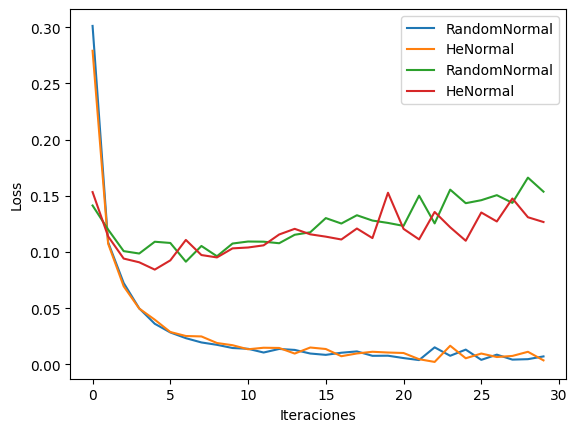

In [24]:
plt.figure()

# for nombre, historia in historias.items():
    # plt.plot(historias.history['loss'], label=nombre) 
#plt.plot(historias['Zeros'].history['loss'], label='Zeros')
#plt.plot(historias['Zeros'].history['val_loss'], label='Zeros')
plt.plot(historias['RandomNormal'].history['loss'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['loss'], label='HeNormal')
plt.plot(historias['RandomNormal'].history['val_loss'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['val_loss'], label='HeNormal')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()
plt.show()

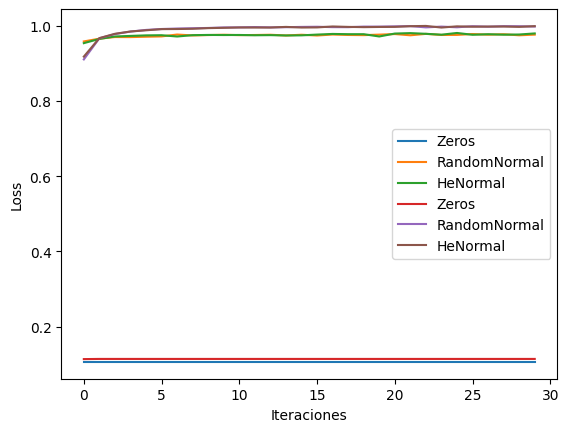

In [25]:
plt.figure()

# for nombre, historia in historias.items():
    # plt.plot(historia.history['val_accuracy'], label=nombre)
plt.plot(historias['Zeros'].history['val_accuracy'], label='Zeros')
plt.plot(historias['RandomNormal'].history['val_accuracy'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['val_accuracy'], label='HeNormal')
plt.plot(historias['Zeros'].history['accuracy'], label='Zeros')
plt.plot(historias['RandomNormal'].history['accuracy'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['accuracy'], label='HeNormal')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()
plt.show()

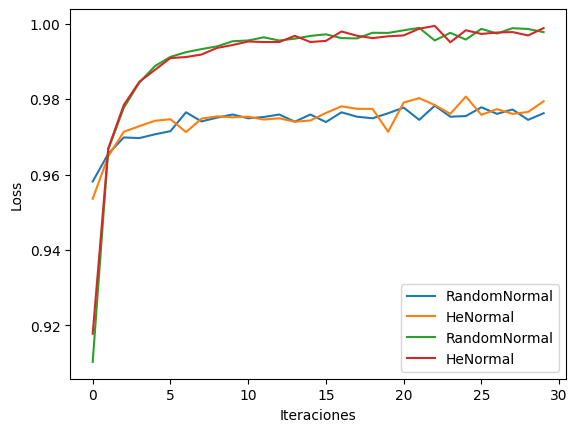

In [26]:
plt.figure()

# for nombre, historia in historias.items():
    # plt.plot(historia.history['val_accuracy'], label=nombre)
#plt.plot(historias['Zeros'].history['val_accuracy'], label='Zeros')
plt.plot(historias['RandomNormal'].history['val_accuracy'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['val_accuracy'], label='HeNormal')
#plt.plot(historias['Zeros'].history['accuracy'], label='Zeros')
plt.plot(historias['RandomNormal'].history['accuracy'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['accuracy'], label='HeNormal')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()
plt.show()

Generar la evaluación

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.9824 - loss: 0.0983
Evaluación del modelo: [0.09825347363948822, 0.9824000000953674]


Técnicas para mejor la generalización
- Regularización
- Drop out

Tipo de modelos:

- El primer modelo es un modelo Henormal
- El segundo es un HeNormal con regularización L2
- El tercer modelo es un HeNormal con regularización L2 con dropout (X%)

¿? para que sirve el input_shape()?

Es un param que le indica a la primera capa como son los datos, en este caso son de 28 * 28, es una imagen aplanada de 28*28

¿Para que sirve el dropout?
20% de dropout

Se coloca al final de cada una de las capas

Se probó con 20, 25 y 15.